# 01 — Deep Agent Baseline on Microsoft Foundry

## Goal

Build the smallest possible Deep Agent using:

- a model deployed in Microsoft Foundry
- Microsoft Entra ID authentication
- the `langchain-azure-ai` Foundry adapter
- the open-source `deepagents` package

We intentionally do **not** add:

- web search
- tracing
- evaluation
- persistent memory
- custom backends
- deployment

The main question for this notebook is:

> How does a Foundry model become something `create_deep_agent()` understands?

---

## Mental model

`create_deep_agent()` does not consume `AIProjectClient`.

It expects a LangChain-compatible chat model.

So our integration boundary is:

Foundry model deployment
        ↓
`AzureAIOpenAIApiChatModel`
        ↓
LangChain `BaseChatModel`
        ↓
`create_deep_agent()`
        ↓
Deep Agents harness
        ↓
LangGraph runtime

## Prerequisites

Before running any notebook in this series:

1. **Sign in with Entra ID** so `DefaultAzureCredential` can acquire a token:

   ```
   az login
   ```

   Your identity needs a data-plane role on the Foundry project
   (for example **Azure AI User**) to call the model and built-in tools.

2. **Create a `.env` file** at the repo root with the values used across notebooks:

   | Variable | Used in | Purpose |
   | --- | --- | --- |
   | `AZURE_AI_PROJECT_ENDPOINT` | 01–04 | Foundry project endpoint |
   | `AZURE_AI_MODEL_DEPLOYMENT_NAME` | 01–04 | Chat/tool-capable model deployment |
   | `APPLICATIONINSIGHTS_CONNECTION_STRING` | 03 | Tracing destination |
   | `AZURE_OPENAI_ENDPOINT` | 04 | Judge model for Azure AI Evaluation |

3. **Install dependencies** with `uv sync` (see the project `pyproject.toml`).

In [2]:
import os

from dotenv import load_dotenv

load_dotenv()

PROJECT_ENDPOINT = os.environ["AZURE_AI_PROJECT_ENDPOINT"]
MODEL_DEPLOYMENT = os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"]

# print("Project endpoint:", PROJECT_ENDPOINT)
# print("Model deployment:", MODEL_DEPLOYMENT)

In [4]:
from azure.ai.projects import AIProjectClient
from azure.identity import DefaultAzureCredential

credential = DefaultAzureCredential()

project_client = AIProjectClient(
    endpoint=PROJECT_ENDPOINT,
    credential=credential,
)

print(type(project_client))

<class 'azure.ai.projects._patch.AIProjectClient'>


In [5]:
openai_client = project_client.get_openai_client()

print(type(openai_client))

<class 'openai.OpenAI'>


In [6]:
response = openai_client.responses.create(
    model=MODEL_DEPLOYMENT,
    input="In one sentence, explain what an AI agent is.",
)

print(response.output_text)

An AI agent is a software system that perceives its environment, makes decisions, and takes actions to achieve specific goals, often using tools and feedback to adapt over time.


## Solve the adapter problem

In [7]:
from azure.identity import DefaultAzureCredential
from langchain_azure_ai.chat_models import AzureAIOpenAIApiChatModel

model = AzureAIOpenAIApiChatModel(
    project_endpoint=PROJECT_ENDPOINT,
    credential=DefaultAzureCredential(),
    model=MODEL_DEPLOYMENT,
)

print(type(model))

<class 'langchain_azure_ai.chat_models.openai.AzureAIOpenAIApiChatModel'>


In [8]:
response = model.invoke(
    "In one sentence, explain the difference between an LLM and an AI agent."
)

response.pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': 'An LLM is a model that generates or understands text, while an AI agent uses an LLM (often plus tools, memory, and planning) to take actions and achieve goals in an environment.', 'annotations': [], 'id': 'msg_0aab3eb3554a3977006a9ca72ad6b08197bfe937babeaf7e84'}]


In [9]:
type(response)

langchain_core.messages.ai.AIMessage

In [15]:
print(response.content[0]['text'])

An LLM is a model that generates or understands text, while an AI agent uses an LLM (often plus tools, memory, and planning) to take actions and achieve goals in an environment.


## Verify tool calling before creating an agent

Deep Agents requires a tool-capable model.

Rather than assuming yours works, let's test it explicitly.

In [16]:
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"The weather in {city} is sunny and 72°F."

In [17]:
model_with_tool = model.bind_tools([get_weather])

response = model_with_tool.invoke(
    "What's the weather in Seattle?"
)

response.pretty_print()

================================== Ai Message ==================================

[{'arguments': '{"city":"Seattle"}', 'call_id': 'call_BsWYU7LlVin8T3CalauBd6Qg', 'name': 'get_weather', 'type': 'function_call', 'id': 'fc_0ffb3ecc3b8049a3006a9ca7f960108190b612e3cca39b5b96', 'status': 'completed', 'response_id': 'resp_0ffb3ecc3b8049a3006a9ca7f8aff081908c639650d6d4d94a'}]
Tool Calls:
  get_weather (call_BsWYU7LlVin8T3CalauBd6Qg)
 Call ID: call_BsWYU7LlVin8T3CalauBd6Qg
  Args:
    city: Seattle


In [18]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'city': 'Seattle'},
  'id': 'call_BsWYU7LlVin8T3CalauBd6Qg',
  'type': 'tool_call'}]

## Build the first Deep Agent

In [19]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=model,
    tools=[get_weather],
    system_prompt="""
You are a helpful technical assistant.

Be concise and use tools when they are appropriate.
""",
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


In [20]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What's the weather in Seattle?",
            }
        ]
    }
)

In [21]:
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Seattle: sunny, 72°F.', 'annotations': [], 'id': 'msg_0dd48284489a928d006a9ca85d770081978a0ec7a2614b303b'}]


In [22]:
for i, message in enumerate(result["messages"]):
    print(f"\n--- MESSAGE {i}: {type(message).__name__} ---")
    print(message)


--- MESSAGE 0: HumanMessage ---
content="What's the weather in Seattle?" additional_kwargs={} response_metadata={} id='7f03b345-da27-4313-8197-54d6684ef674'

--- MESSAGE 1: AIMessage ---
content=[{'arguments': '{"city":"Seattle"}', 'call_id': 'call_cndtO9po5L7OvGqw7QlnPyY9', 'name': 'get_weather', 'type': 'function_call', 'id': 'fc_0dd48284489a928d006a9ca85a64a88197a8aed26aff6ff41f', 'status': 'completed', 'response_id': 'resp_0dd48284489a928d006a9ca857b23081979443ad9335ecdef6'}] additional_kwargs={} response_metadata={'id': 'resp_0dd48284489a928d006a9ca857b23081979443ad9335ecdef6', 'created_at': 1788651607.0, 'metadata': {}, 'model': 'gpt-5.2', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.2'} id='resp_0dd48284489a928d006a9ca857b23081979443ad9335ecdef6' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Seattle'}, 'id': 'call_cndtO9po5L7OvGqw7QlnPyY9', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metad

## Discover what Deep Agents adds automatically

In [23]:
workspace_result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": """
Create a short note explaining three differences between
a normal LLM call and an AI agent.

Use your filesystem to write the note to /agent_notes.md,
read it back to verify it, and then summarize the note for me.
""",
            }
        ]
    }
)

print(workspace_result["messages"][-1].content)

[{'type': 'text', 'text': 'I wrote the note to `/agent_notes.md` and read it back to verify its contents.\n\nSummary of the note (three differences):\n1. **Execution pattern:** A normal LLM call is usually single prompt → single response, while an **AI agent** runs an iterative loop (plan → act → evaluate → repeat) to reach a goal.\n2. **Capabilities:** A normal LLM call mainly outputs text/structured text, while an **AI agent** can use tools and interact with external systems (APIs, search, code execution, files, etc.) and incorporate results.\n3. **State/memory:** A normal LLM call is effectively **stateless** beyond the provided prompt, while an **AI agent** often maintains managed state/working memory and may persist longer-term memory across steps.', 'annotations': [], 'id': 'msg_03f65c2262dc8cbb006a9ca8bf62cc819497efa2393d91e072'}]


In [24]:
for i, message in enumerate(workspace_result["messages"]):
    print(f"\n--- MESSAGE {i}: {type(message).__name__} ---")

    if hasattr(message, "tool_calls") and message.tool_calls:
        print("TOOL CALLS:")
        for tool_call in message.tool_calls:
            print(tool_call)

    else:
        print(message.content)


--- MESSAGE 0: HumanMessage ---

Create a short note explaining three differences between
a normal LLM call and an AI agent.

Use your filesystem to write the note to /agent_notes.md,
read it back to verify it, and then summarize the note for me.


--- MESSAGE 1: AIMessage ---
TOOL CALLS:
{'name': 'write_file', 'args': {'file_path': '/agent_notes.md', 'content': '# Normal LLM call vs. AI agent — three differences\n\n1) **Single-step response vs. goal-directed loop**\n   - A normal LLM call typically takes one prompt and returns one completion.\n   - An AI agent is usually *iterative*: it plans, executes, evaluates results, and repeats until it meets a goal or hits a stop condition.\n\n2) **No external actions vs. tool use and environment interaction**\n   - A normal LLM call only produces text (or structured text) and cannot directly affect the outside world.\n   - An AI agent can call tools/APIs (search, code execution, databases, file I/O, web requests) and use the outputs to decide

## Inspect the LangGraph underneath

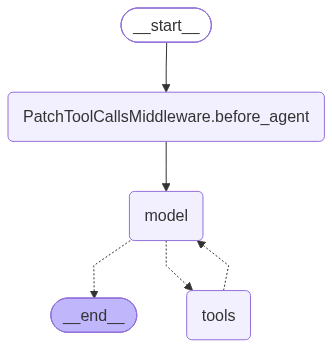

In [30]:
from IPython.display import Image, display

graph = agent.get_graph()

display(Image(graph.draw_mermaid_png()))

In [31]:
print(graph.nodes.keys())

dict_keys(['__start__', 'model', 'tools', 'PatchToolCallsMiddleware.before_agent', '__end__'])


# What we learned

## 1. Foundry SDK and LangChain solve different problems

Raw Microsoft API:

```
Foundry
↓
AIProjectClient
↓
OpenAI-compatible Responses API
```

Framework integration:

```
Foundry
↓
AzureAIOpenAIApiChatModel
↓
LangChain model contract
↓
Deep Agents
```

## 2. `create_deep_agent()` does not require a LangChain-hosted service

It needs a LangChain-compatible **model object**, not LangSmith.

Our model happens to be hosted in Microsoft Foundry.


## 3. Deep Agents is a harness, not a model service

Deep Agents adds capabilities around the normal tool-calling loop:

- virtual filesystem
- context management
- subagent delegation
- long-running work
- optional planning
- middleware

LangGraph provides the execution runtime underneath.


## 4. Current architecture

```
User
  ↓
Deep Agent
  ↓
LangGraph runtime
  ↓
LangChain Foundry adapter
  ↓
Microsoft Foundry model
```

## 5. Still intentionally missing

- real web search
- tracing
- evaluation
- persistence
- deployment
- Azure hosting

Those will be introduced one capability at a time.